In [12]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.filters import sobel, threshold_otsu
from skimage.feature import canny

from time import perf_counter

from pathlib import Path

ROOT_DIR = Path.cwd().parent
PENTAGON_PATH = ROOT_DIR / "data/lr3/pentagon.png"
print("Корневой путь:", ROOT_DIR)
print("Путь к изображению:", PENTAGON_PATH, "\n")

image = imread(PENTAGON_PATH)
print(f"Изображение: {image.shape}, dtype={image.dtype}")

Корневой путь: /home/rixen42/Study/pattern-recognition
Путь к изображению: /home/rixen42/Study/pattern-recognition/data/lr3/pentagon.png 

Изображение: (928, 1664, 3), dtype=uint8


## Часть 1

In [13]:
# RGB to gray and [0, 1]
if image.ndim == 3:
    image = rgb2gray(image)

image = img_as_float(image)


# -----//----- Sobel -----//-----
# skimage.filters.sobel возвращает карту градиента, а не бинарную маску. 
# Поэтому нужно выбрать порог.
G = sobel(image)

try:
    t_sobel = threshold_otsu(G)
except ValueError:
    t_sobel = 0.1 * G.max() if G.max() > 0 else 0.0

E1 = G > t_sobel
# E1 = G > 0.10
# E1 = G > 0.15

# -----//----- Canny -----//-----
# low_threshold и high_threshold задаются для градиента.
# Для изображения в диапазоне [0, 1] обычно подходят значения вида 0.05...0.2.
E2 = canny(
    image,
    sigma=1.0,
    low_threshold=0.10,
    high_threshold=0.20
)

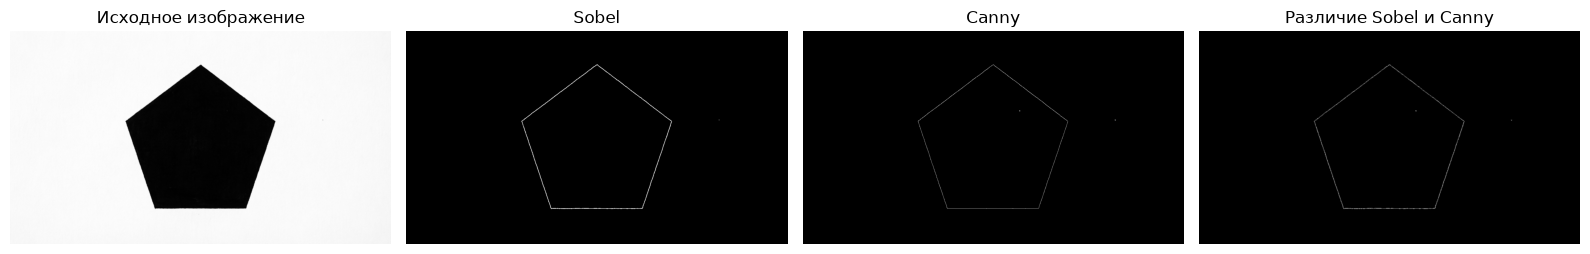

Порог для Sobel: 0.22279555685870606
Количество пикселей границы после Sobel: 5178
Количество пикселей границы после Canny: 2346
IoU для двух масок границ: 0.448


In [15]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Исходное изображение')

ax[1].imshow(E1, cmap='gray')
ax[1].set_title('Sobel')

ax[2].imshow(E2, cmap='gray')
ax[2].set_title('Canny')

ax[3].imshow(E1 ^ E2, cmap='gray')
ax[3].set_title('Различие Sobel и Canny')

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()


# --- Количественное сравнение ---
print('Порог для Sobel:', t_sobel)
print('Количество пикселей границы после Sobel:', np.count_nonzero(E1))
print('Количество пикселей границы после Canny:', np.count_nonzero(E2))

intersection = np.logical_and(E1, E2).sum()
union = np.logical_or(E1, E2).sum()

iou = intersection / union if union > 0 else 0.0
print(f'IoU для двух масок границ: {iou:.3f}')

## Часть 2

In [ ]:
try:
    A = imread(PENTAGOT_PATH)
except Exception:
    A = data.camera()
    print(f"Файл {PENTAGOT_PATH} не найден. Для проверки использую тестовое изображение.")

if A.ndim == 3:
    A = rgb2gray(A)

A = img_as_float(A)

h, w = A.shape


# Поиск границ
E = canny(A, sigma=1.0)


# Пространство параметров <k, b>

KMAX = 1000
BMAX = 1000

kmax = 5.0
bmax = 1000.0

# Постоянные множители выносим заранее
k_scale = (2 * kmax) / (KMAX - 1)
b_scale = (BMAX - 1) / (2 * bmax)

H = np.zeros((KMAX, BMAX), dtype=np.int32)


# -----//----- Медленный вариант для сравнения -----//-----

def hough_kb_slow(E, KMAX, BMAX, kmax, bmax):
    h, w = E.shape
    H = np.zeros((KMAX, BMAX), dtype=np.int32)

    for x in range(w):
        for y in range(h):
            if E[y, x] == 0:
                continue

            for KI in range(KMAX):
                k = KI * (2 * kmax) / (KMAX - 1) - kmax
                b = -x * k + y

                BI = int(round((b + bmax) * (BMAX - 1) / (2 * bmax)))

                if 0 <= BI < BMAX:
                    H[KI, BI] += 1

    return H


# -----//----- Быстрый вариант с вынесенными множителями -----//-----

def hough_kb_fast(E, KMAX, BMAX, kmax, bmax):
    h, w = E.shape
    H = np.zeros((KMAX, BMAX), dtype=np.int32)

    # Постоянные множители
    k_scale = (2 * kmax) / (KMAX - 1)
    b_scale = (BMAX - 1) / (2 * bmax)

    # Заранее подготовленные значения k для всех KI
    KI_values = np.arange(KMAX)
    k_values = KI_values * k_scale - kmax

    for x in range(w):
        for y in range(h):
            if E[y, x] == 0:
                continue

            # Для всех k сразу считаем b
            b_values = -x * k_values + y

            # Переводим b в индексы
            BI_values = np.rint((b_values + bmax) * b_scale).astype(np.int32)

            # Оставляем только допустимые индексы
            valid = (BI_values >= 0) & (BI_values < BMAX)

            if np.any(valid):
                H[KI_values[valid], BI_values[valid]] += 1

    return H


# -----//----- Замер времени -----//-----

# Для медленного варианта можно ограничить область,
# иначе он может работать очень долго.
# Например, взять уменьшенную копию изображения.

# Чтобы сравнение было честным, можно взять подмножество точек границы.
# Но для демонстрации можно запустить медленный вариант на небольшом изображении.

# Здесь можно уменьшить изображение для быстрого теста:
E_small = E[:200, :200]

t0 = perf_counter()
H_slow_small = hough_kb_slow(E_small, KMAX, BMAX, kmax, bmax)
t_slow = perf_counter() - t0

t0 = perf_counter()
H_fast_small = hough_kb_fast(E_small, KMAX, BMAX, kmax, bmax)
t_fast = perf_counter() - t0

speedup = t_slow / t_fast if t_fast > 0 else float("inf")
gain = (t_slow - t_fast) / t_slow * 100 if t_slow > 0 else 0.0

print("=== Часть 2: ускорение за счёт выноса постоянных множителей ===")
print(f"Медленный вариант: {t_slow:.6f} c")
print(f"Быстрый вариант: {t_fast:.6f} c")
print(f"Ускорение: {speedup:.2f} раза")
print(f"Прирост производительности: {gain:.1f}%")


# -----//----- Полный быстрый вариант на всём изображении -----//-----

t0 = perf_counter()
H_full = hough_kb_fast(E, KMAX, BMAX, kmax, bmax)
t_full = perf_counter() - t0

print(f"\nВремя полного быстрого преобразования на всём изображении: {t_full:.6f} c")

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(H_full.T, aspect="auto", origin="lower", cmap="inferno")
plt.title("Пространство поиска <k, b>")
plt.xlabel("KI")
plt.ylabel("BI")
plt.colorbar(label="Количество голосов")
plt.tight_layout()

plt.show()

## Часть 3

## Часть 4